# Week 9: Change Detection & Validation — ARIA v6.0
## 第九週：變化偵測與驗證 — ARIA v6.0（經過驗證的稽核員）

**Course**: 遙測與空間資訊之分析與應用 | Remote Sensing Analysis & Applications
**Institution**: National Taiwan University (NTU)
**Instructor**: Prof. Su Wen-Ray (蘇文瑄教授)
**Case Study**: Matai'an Barrier Lake (Typhoon Colo)

### Lab Rhythm / 實驗時間分配
| Lab | Topic | Duration | 主題 |
|-----|-------|----------|------|
| **Lab 1** | Difference Mapping (NDVI/NDWI) | 35 min | 差異圖製作 |
| **Lab 2** | Accuracy Assessment & Validation | 50 min | 精度評估與驗證 |

---

### Context / 背景知識
Pre-event baseline (Jun 2025) → Disaster onset (Aug 2025) → Post-event recovery (Oct 2025)

**Study area (Matai'an)**: [121.28, 23.56, 121.52, 23.76]
**Key indices**: NDVI (vegetation), NDWI (water)


## Lab 1: Difference Mapping — Which Index Reveals the Lake?
### 實驗1：差異圖製作 — 哪個指標最清楚顯示水位變化？

**Objective**: Compute spectral indices (NDVI, NDWI) for three temporal scenes, create difference maps, and explore threshold sensitivity.

**步驟**:
1. Load Sentinel-2 imagery from STAC
2. Compute NDVI and NDWI for each scene
3. Create difference maps: ΔIndex = Mid - Pre, Post - Mid
4. Plot 2×2 panel showing change
5. Sweep threshold and visualize detection area


In [5]:
# [S1] Environment Setup
# ──────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Additional libraries
import json
import os

from pystac_client import Client
from odc.stac import load as stac_load
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    f1_score
)

import planetary_computer as pc
import stackstac

# Configuration
MATAIAN_BBOX = [121.28, 23.56, 121.52, 23.76]  # [W, S, E, N]

# ── Lake-focused AOI (NEW in W9) ──
# The barrier lake is ~1 km² in the upper-left of the 24×20 km scene.
# Using the full scene inflates OA with trivially-correct "stable" pixels.
# ── 堰塞湖只有 ~1 km²，用全場景會讓大量穩定像素灌水 OA。
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]   # ~5×4 km around lake

# ── SCL cloud masking (NEW in W9) ──
# SCL (Scene Classification Layer) classifies each pixel:
#   0=No data, 1=Saturated, 2=Dark, 3=Cloud shadow,
#   4=Vegetation, 5=Bare soil, 6=Water, 7=Unclassified,
#   8=Cloud (medium), 9=Cloud (high), 10=Thin cirrus, 11=Snow/ice
# We keep classes that represent clear-sky surface pixels.
# ── 保留代表晴空地表的類別。
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]


def safe_compute(x):
    """
    Safely compute xarray/dask-backed objects.
    If the object has .compute(), compute it; otherwise return as-is.
    """
    try:
        return x.compute() if hasattr(x, "compute") else x
    except Exception:
        return x


def stream_scl(item, bbox=MATAIAN_BBOX, epsg=32651, resolution=10, chunksize=2048):
    """
    Stream Sentinel-2 SCL band and return boolean clear-sky mask.

    Parameters
    ----------
    item : pystac.Item
        STAC item of a Sentinel-2 scene.
    bbox : list
        Bounding box in lon/lat [W, S, E, N].
    epsg : int
        Target CRS EPSG code.
    resolution : int
        Output pixel size in meters.
    chunksize : int
        Chunk size for stackstac.

    Returns
    -------
    np.ndarray
        Boolean mask where True means clear-sky usable pixel.
    """
    signed = pc.sign(item)

    scl = stackstac.stack(
        [signed],
        assets=["SCL"],
        epsg=epsg,
        resolution=resolution,
        bounds_latlon=bbox,
        chunksize=chunksize
    ).squeeze("time", drop=True).squeeze("band", drop=True)

    scl_data = safe_compute(scl)
    return np.isin(scl_data.values, SCL_CLEAR_CLASSES)


OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✓ Environment setup complete")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Study area BBOX: {MATAIAN_BBOX}")
print(f"  Lake-focused BBOX: {LAKE_BBOX_LONLAT}")
print(f"  Clear SCL classes: {SCL_CLEAR_CLASSES}")

✓ Environment setup complete
  Output directory: ../output
  Study area BBOX: [121.28, 23.56, 121.52, 23.76]
  Lake-focused BBOX: [121.27, 23.68, 121.32, 23.72]
  Clear SCL classes: [2, 4, 5, 6, 7, 11]


In [6]:
# [S2] Search and Load Three-Act Scenes
# ──────────────────────────────────────────────────────────────────
# Search STAC for Pre, Mid, Post scenes of Matai'an barrier lake

# Scene dates (three acts of the disaster narrative)
SCENE_DATES = {
    "Pre": "2025-06-01",    # Baseline (before typhoon)
    "Mid": "2025-08-15",    # Lake present at peak
    "Post": "2025-10-10"    # Lake drained / recovered
}

STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
COLLECTION = "sentinel-2-l2a"

# Open STAC client
client = Client.open(STAC_URL)


def _to_z(ts):
    """Convert pandas Timestamp to UTC Z string."""
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    return ts.strftime("%Y-%m-%dT%H:%M:%SZ")


def choose_best_item(items, target_date):
    """
    Choose the best STAC item using:
    1) minimum absolute date difference to target_date
    2) lower cloud cover
    """
    target_dt = pd.Timestamp(target_date).tz_localize("UTC")

    def sort_key(item):
        item_dt = pd.Timestamp(item.datetime)
        if item_dt.tzinfo is None:
            item_dt = item_dt.tz_localize("UTC")
        else:
            item_dt = item_dt.tz_convert("UTC")

        delta_sec = abs((item_dt - target_dt).total_seconds())
        cloud = item.properties.get("eo:cloud_cover", np.inf)
        return (delta_sec, cloud, item.id)

    return sorted(items, key=sort_key)[0]


def robust_search(
    client,
    bbox,
    target_date,
    collection=COLLECTION,
    search_windows=(0, 3, 7, 14, 21, 30),
    cloud_thresholds=(20, 40, 80, None),
    max_items=50
):
    """
    Robust STAC search:
    - search progressively wider date windows
    - relax cloud-cover filter if needed
    - return the best item
    """
    target_dt = pd.Timestamp(target_date).tz_localize("UTC")

    for cloud_limit in cloud_thresholds:
        for window_days in search_windows:
            start_dt = target_dt - pd.Timedelta(days=window_days)
            end_dt = target_dt + pd.Timedelta(days=window_days)

            search_kwargs = {
                "collections": [collection],
                "bbox": bbox,
                "datetime": f"{_to_z(start_dt)}/{_to_z(end_dt)}",
                "max_items": max_items,
            }

            if cloud_limit is not None:
                search_kwargs["query"] = {"eo:cloud_cover": {"lt": cloud_limit}}

            try:
                results = client.search(**search_kwargs)
                items = list(results.item_collection())

                if len(items) > 0:
                    best_item = choose_best_item(items, target_date)
                    info = {
                        "window_days": window_days,
                        "cloud_limit": cloud_limit,
                        "n_candidates": len(items),
                        "selected_id": best_item.id,
                        "selected_datetime": str(best_item.datetime),
                        "selected_cloud": best_item.properties.get("eo:cloud_cover", "N/A")
                    }
                    return best_item, info

            except Exception as e:
                print(f"  Search failed for ±{window_days} days, cloud<{cloud_limit}: {e}")

    return None, None


# Search scenes
scenes = {}
scene_info = {}

for act, date in SCENE_DATES.items():
    print(f"Searching {act} ({date}) ...")
    item, info = robust_search(
        client=client,
        bbox=MATAIAN_BBOX,
        target_date=date,
        collection=COLLECTION
    )

    if item is None:
        print(f"  ✗ No scene found for {act}")
    else:
        scenes[act] = item
        scene_info[act] = info
        print(f"  ✓ Selected: {info['selected_id']}")
        print(f"    datetime     : {info['selected_datetime']}")
        print(f"    cloud cover  : {info['selected_cloud']}")
        print(f"    search window: ±{info['window_days']} days")
        print(f"    candidates   : {info['n_candidates']}")

print("✓ Scene search complete")
print(f"  Scenes found: {list(scenes.keys())}")

Searching Pre (2025-06-01) ...
  ✓ Selected: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
    datetime     : 2025-06-15 02:31:41.024000+00:00
    cloud cover  : 8.501057
    search window: ±21 days
    candidates   : 1
Searching Mid (2025-08-15) ...
  ✓ Selected: S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827
    datetime     : 2025-08-17 02:25:39.024000+00:00
    cloud cover  : 17.585771
    search window: ±3 days
    candidates   : 1
Searching Post (2025-10-10) ...
  ✓ Selected: S2C_MSIL2A_20251011T022641_R046_T51QUG_20251011T061121
    datetime     : 2025-10-11 02:26:41.025000+00:00
    cloud cover  : 17.947668
    search window: ±3 days
    candidates   : 1
✓ Scene search complete
  Scenes found: ['Pre', 'Mid', 'Post']


In [7]:
# [S3] Load and Composite Multi-Spectral Cubes
# ──────────────────────────────────────────────────────────────────
# Reference bands: B02 (Blue), B03 (Green), B04 (Red), B08 (NIR), B11 (SWIR)

BANDS = ["B02", "B03", "B04", "B08", "B11"]
BAND_NAMES = {
    "B02": "Blue",
    "B03": "Green",
    "B04": "Red",
    "B08": "NIR",
    "B11": "SWIR"
}


def stream_cube(
    scene_item,
    bands,
    bbox=MATAIAN_BBOX,
    epsg=32651,
    resolution=10,
    chunksize=2048
):
    """
    Load Sentinel-2 bands from a STAC item and stack into cube (H, W, C).
    Output is scaled from reflectance DN to [roughly 0, 1].
    """
    signed = pc.sign(scene_item)

    arr = stackstac.stack(
        [signed],
        assets=bands,
        epsg=epsg,
        resolution=resolution,
        bounds_latlon=bbox,
        chunksize=chunksize
    ).squeeze("time", drop=True)

    arr = safe_compute(arr).transpose("y", "x", "band")
    cube = arr.values.astype(np.float32) / 10000.0
    return cube


def composite_stretched(cube, r_idx=2, g_idx=1, b_idx=0, q=(2, 98)):
    """
    Create RGB composite with percentile-based contrast stretch.
    Default: true color RGB = Red, Green, Blue
    """
    rgb = cube[:, :, [r_idx, g_idx, b_idx]].copy()

    for i in range(3):
        band = rgb[:, :, i]
        finite_mask = np.isfinite(band)

        if finite_mask.sum() == 0:
            rgb[:, :, i] = 0
            continue

        p_lo, p_hi = np.nanpercentile(band[finite_mask], q)

        if np.isclose(p_hi, p_lo):
            rgb[:, :, i] = np.where(finite_mask, 0, np.nan)
        else:
            stretched = (band - p_lo) / (p_hi - p_lo)
            rgb[:, :, i] = np.clip(stretched, 0, 1)

    rgb[~np.isfinite(rgb)] = 0
    return rgb


# Convenience references
pre_item = scenes["Pre"]
mid_item = scenes["Mid"]
post_item = scenes["Post"]

# Load cubes and RGB composites
cubes = {}
composites = {}

for act in ["Pre", "Mid", "Post"]:
    print(f"Loading {act}...")
    cubes[act] = stream_cube(scenes[act], BANDS)
    composites[act] = composite_stretched(cubes[act])

# Extract NIR bands for mask logic (B08 index = 3)
nir_pre = cubes["Pre"][:, :, 3]
nir_mid = cubes["Mid"][:, :, 3]
nir_post = cubes["Post"][:, :, 3]

# ── Cloud masking (CRITICAL — without this, ΔNDWI shows "phantom water") ──
clear_pre = stream_scl(pre_item)
clear_mid = stream_scl(mid_item)
clear_post = stream_scl(post_item)

# ── Per-scene valid masks (for Three-Act visualization) ──
# Each scene uses its OWN mask so students can see Mid has more clouds.
valid_pre = np.isfinite(nir_pre) & clear_pre
valid_mid = np.isfinite(nir_mid) & clear_mid
valid_post = np.isfinite(nir_post) & clear_post

# ── Intersection mask (for difference maps where BOTH dates must be valid) ──
valid_raw = np.isfinite(nir_pre) & np.isfinite(nir_mid) & np.isfinite(nir_post)
valid = valid_raw & clear_pre & clear_mid & clear_post

# Optional dictionaries for later use
clear_masks = {
    "Pre": clear_pre,
    "Mid": clear_mid,
    "Post": clear_post
}

valid_masks = {
    "Pre": valid_pre,
    "Mid": valid_mid,
    "Post": valid_post,
    "Intersection": valid
}

print("✓ Cubes loaded and composited")
print(f"  Cube shape: (H, W, C) = {list(cubes.values())[0].shape if cubes else 'N/A'}")
print(f"  Pre clear pixels : {clear_pre.sum():,}")
print(f"  Mid clear pixels : {clear_mid.sum():,}")
print(f"  Post clear pixels: {clear_post.sum():,}")
print(f"  Valid intersection pixels: {valid.sum():,}")

Loading Pre...
Loading Mid...
Loading Post...
✓ Cubes loaded and composited
  Cube shape: (H, W, C) = (2243, 2474, 5)
  Pre clear pixels : 5,470,540
  Mid clear pixels : 4,069,926
  Post clear pixels: 4,327,696
  Valid intersection pixels: 3,193,095


### Computing Spectral Indices: NDVI & NDWI
### 計算光譜指標：NDVI & NDWI

**NDVI** = (NIR - Red) / (NIR + Red)
**NDWI** = (Green - NIR) / (Green + NIR)

─

Why two indices?
- **NDVI**: Sensitive to vegetation density, but also responds to water
- **NDWI**: Maximally sensitive to open water and wetlands

─

為何使用兩種指標？
- **NDVI**：對植被濃度敏感，但也對水體有反應
- **NDWI**：對開放水體和濕地最敏感


In [8]:
# [S4] Compute NDVI and NDWI for All Three Scenes
# ──────────────────────────────────────────────────────────────────

def ndvi(cube):
    """Compute NDVI from cube (B04=Red at idx 2, B08=NIR at idx 3)."""
    red = cube[:, :, 2].astype(np.float32)
    nir = cube[:, :, 3].astype(np.float32)
    out = (nir - red) / (nir + red + 1e-8)
    return np.clip(out, -1.0, 1.0)


def ndwi(cube):
    """Compute NDWI from cube (B03=Green at idx 1, B08=NIR at idx 3)."""
    green = cube[:, :, 1].astype(np.float32)
    nir = cube[:, :, 3].astype(np.float32)
    out = (green - nir) / (green + nir + 1e-8)
    return np.clip(out, -1.0, 1.0)


def apply_mask(arr, mask):
    """Set invalid pixels to NaN for safer stats/visualization."""
    out = arr.astype(np.float32).copy()
    out[~mask] = np.nan
    return out


# Compute indices for all three scenes
indices = {}

for act in ["Pre", "Mid", "Post"]:
    ndvi_raw = ndvi(cubes[act])
    ndwi_raw = ndwi(cubes[act])

    indices[act] = {
        "NDVI": apply_mask(ndvi_raw, valid_masks[act]),
        "NDWI": apply_mask(ndwi_raw, valid_masks[act]),
        "NDVI_raw": ndvi_raw,   # keep raw version in case later cells need it
        "NDWI_raw": ndwi_raw
    }


# Print summary statistics (masked / valid pixels only)
for act in ["Pre", "Mid", "Post"]:
    print(f"{act} scene:")
    for idx_name in ["NDVI", "NDWI"]:
        idx = indices[act][idx_name]
        print(
            f"  {idx_name}: "
            f"μ={np.nanmean(idx):.3f}, "
            f"σ={np.nanstd(idx):.3f}, "
            f"[{np.nanmin(idx):.3f}, {np.nanmax(idx):.3f}]"
        )

print("✓ NDVI and NDWI computed")

Pre scene:
  NDVI: μ=0.521, σ=0.156, [-0.281, 0.738]
  NDWI: μ=-0.459, σ=0.137, [-0.813, 0.358]
Mid scene:
  NDVI: μ=0.502, σ=0.189, [-0.298, 0.876]
  NDWI: μ=-0.443, σ=0.168, [-0.745, 0.414]
Post scene:
  NDVI: μ=0.471, σ=0.182, [-0.253, 0.803]
  NDWI: μ=-0.431, σ=0.165, [-0.735, 0.372]
✓ NDVI and NDWI computed


Mid-Pre:
  ΔNDVI: μ=-0.016, σ=0.109, [-0.907, 0.642]
  ΔNDWI: μ=0.013, σ=0.093, [-0.554, 0.969]
Post-Mid:
  ΔNDVI: μ=-0.024, σ=0.121, [-0.739, 0.705]
  ΔNDWI: μ=0.006, σ=0.105, [-0.703, 0.683]


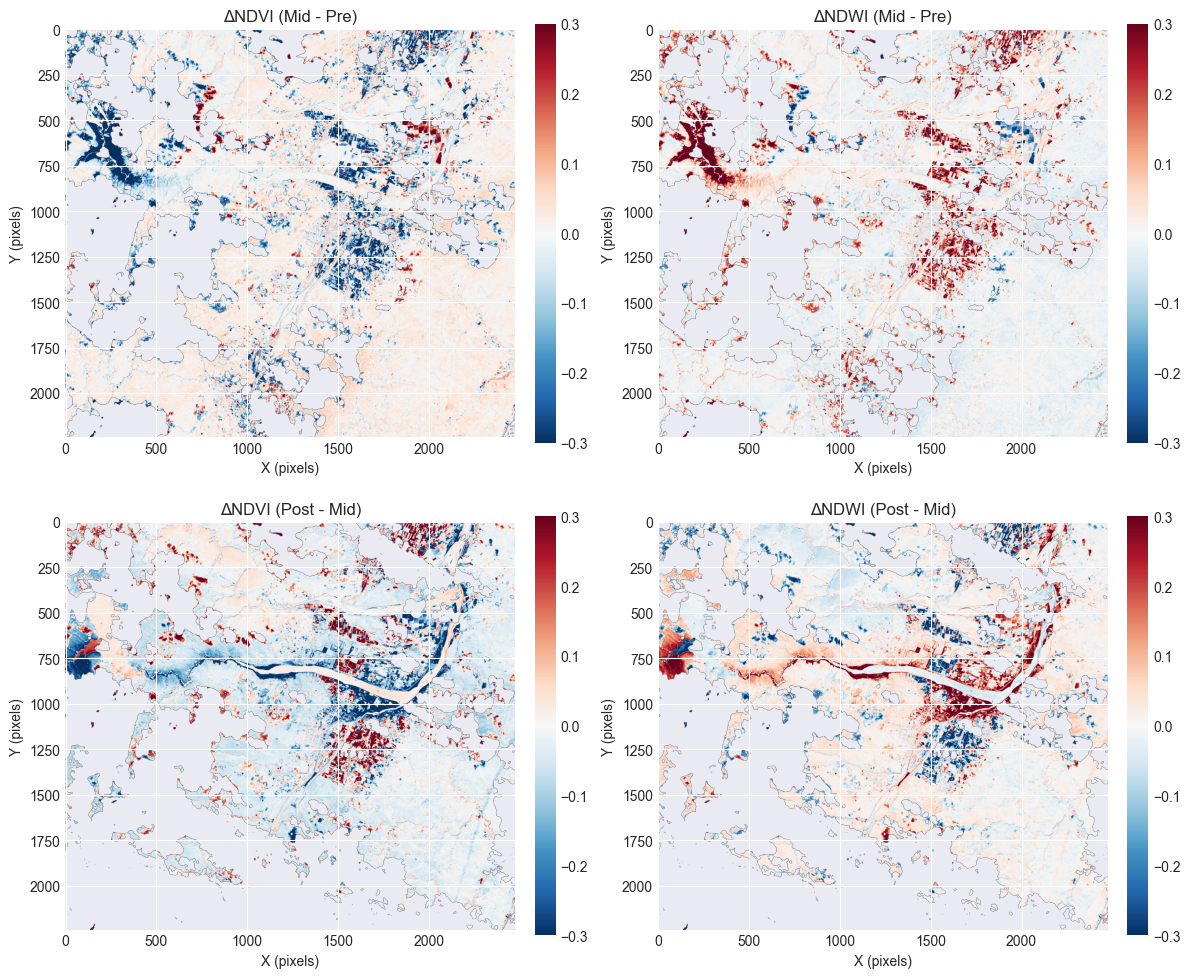

✓ Difference maps created
  Output: ../output/W9_L1_difference_maps.png


In [9]:
# [S5] Create Difference Maps: ΔIndex and Visualize 2×2 Panel
# ──────────────────────────────────────────────────────────────────

def masked_difference(a, b, mask):
    """Compute difference a - b, keeping only pixels where mask=True."""
    out = (a - b).astype(np.float32)
    out[~mask] = np.nan
    return out


# Pairwise valid masks for each transition
valid_mid_pre = valid_masks["Mid"] & valid_masks["Pre"]
valid_post_mid = valid_masks["Post"] & valid_masks["Mid"]

# Compute difference maps
d_ndvi = {}
d_ndwi = {}

# Mid - Pre
d_ndvi["Mid-Pre"] = masked_difference(
    indices["Mid"]["NDVI"], indices["Pre"]["NDVI"], valid_mid_pre
)
d_ndwi["Mid-Pre"] = masked_difference(
    indices["Mid"]["NDWI"], indices["Pre"]["NDWI"], valid_mid_pre
)

# Post - Mid
d_ndvi["Post-Mid"] = masked_difference(
    indices["Post"]["NDVI"], indices["Mid"]["NDVI"], valid_post_mid
)
d_ndwi["Post-Mid"] = masked_difference(
    indices["Post"]["NDWI"], indices["Mid"]["NDWI"], valid_post_mid
)

# Print summary statistics
for transition in ["Mid-Pre", "Post-Mid"]:
    print(f"{transition}:")
    print(
        f"  ΔNDVI: μ={np.nanmean(d_ndvi[transition]):.3f}, "
        f"σ={np.nanstd(d_ndvi[transition]):.3f}, "
        f"[{np.nanmin(d_ndvi[transition]):.3f}, {np.nanmax(d_ndvi[transition]):.3f}]"
    )
    print(
        f"  ΔNDWI: μ={np.nanmean(d_ndwi[transition]):.3f}, "
        f"σ={np.nanstd(d_ndwi[transition]):.3f}, "
        f"[{np.nanmin(d_ndwi[transition]):.3f}, {np.nanmax(d_ndwi[transition]):.3f}]"
    )

# Create 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(d_ndvi["Mid-Pre"], cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[0, 0].set_title("ΔNDVI (Mid - Pre)")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(d_ndwi["Mid-Pre"], cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[0, 1].set_title("ΔNDWI (Mid - Pre)")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 0].imshow(d_ndvi["Post-Mid"], cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1, 0].set_title("ΔNDVI (Post - Mid)")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

im3 = axes[1, 1].imshow(d_ndwi["Post-Mid"], cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[1, 1].set_title("ΔNDWI (Post - Mid)")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

for ax in axes.flat:
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L1_difference_maps.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Difference maps created")
print(f"  Output: {OUTPUT_DIR}/W9_L1_difference_maps.png")

### Error Case: What Happens WITHOUT Cloud Masking?
### 錯誤案例：不做雲遮罩會怎樣？

Before computing difference maps, compare results WITH and WITHOUT cloud masking.
This demonstrates why SCL masking is **mandatory** for change detection.

**Task**: Create a 3-panel comparison:
1. ❌ ΔNDWI without cloud mask (`valid_raw`) — "phantom water" everywhere
2. ✅ ΔNDWI with cloud mask (`valid`) — only real water changes
3. 🔍 ΔNDWI zoomed to lake AOI (`LAKE_BBOX_LONLAT`) — focused view

── 計算差異圖之前，比較有無雲遮罩的結果。
── 這展示了為什麼 SCL 遮罩在變遷偵測中是**必要的**。


### Discussion: Which Index Shows the Barrier Lake Best?
### 討論：哪個指標最清楚顯示障礙湖？

**Observations** (from the 2×2 panel):

1. **ΔNDVI (Mid - Pre)**: Does vegetation decrease at the lake site? Why might it stay positive?
   - NDVI = (NIR - Red)/(NIR + Red) → water has low NDVI, but may not be negative

2. **ΔNDWI (Mid - Pre)**: Is this more clearly showing water presence?
   - NDWI = (Green - NIR)/(Green + NIR) → water has high NDWI

3. **Recovery phase (Post - Mid)**: Do both indices return to baseline?

─

**Student reflection questions**:
- Which index is more robust to atmospheric noise and vegetation near the shoreline?
- Why might NDWI be designed specifically for water detection?
- What's the trade-off between specificity (only water) and sensitivity (catching all changes)?


- **哪個指標對大氣雜訊與湖岸植被較穩健？**  
  一般而言，**NDWI 較穩健**。因為 NDWI 是針對水體偵測設計，能更直接突顯水面訊號；相較之下，NDVI 主要反映植被狀態，當湖岸周邊有植被、潮濕土壤或混合像元時，較容易受到干擾，判讀水體也較不直接。

- **為什麼 NDWI 是專門為水體偵測而設計的？**  
  因為水體在光譜上通常表現為 **綠光相對較高、近紅外光很低**，所以 NDWI 使用 Green 與 NIR 的組合，可以有效放大水體與非水體之間的差異，使水域在影像中更容易被辨識出來。

- **Specificity（只抓真正的水）與 Sensitivity（盡量抓到所有變化）之間的取捨是什麼？**  
  若提高 **specificity**，門檻通常會設得較嚴格，可減少誤判，但也可能漏掉一些真實水體；若提高 **sensitivity**，門檻通常會較寬鬆，能抓到更多可能的水域變化，但也更容易把雜訊、陰影或混合像元誤判為水體。也就是說，兩者的取捨在於：**要更保守避免誤報，還是更積極避免漏判。**

Threshold sensitivity summary:
  t=0.00 | Mid-Pre appearing area = 1,732,971 px | Post-Mid draining area = 1,433,485 px
  t=0.02 | Mid-Pre appearing area =  997,927 px | Post-Mid draining area =  890,232 px
  t=0.04 | Mid-Pre appearing area =  696,930 px | Post-Mid draining area =  563,289 px
  t=0.06 | Mid-Pre appearing area =  549,807 px | Post-Mid draining area =  388,156 px
  t=0.08 | Mid-Pre appearing area =  455,017 px | Post-Mid draining area =  294,486 px
  t=0.10 | Mid-Pre appearing area =  385,958 px | Post-Mid draining area =  238,710 px
  t=0.12 | Mid-Pre appearing area =  332,540 px | Post-Mid draining area =  199,699 px
  t=0.14 | Mid-Pre appearing area =  288,968 px | Post-Mid draining area =  169,762 px
  t=0.16 | Mid-Pre appearing area =  252,017 px | Post-Mid draining area =  146,394 px
  t=0.18 | Mid-Pre appearing area =  219,988 px | Post-Mid draining area =  126,981 px
  t=0.20 | Mid-Pre appearing area =  191,920 px | Post-Mid draining area =  110,566 px
  t=0.22 |

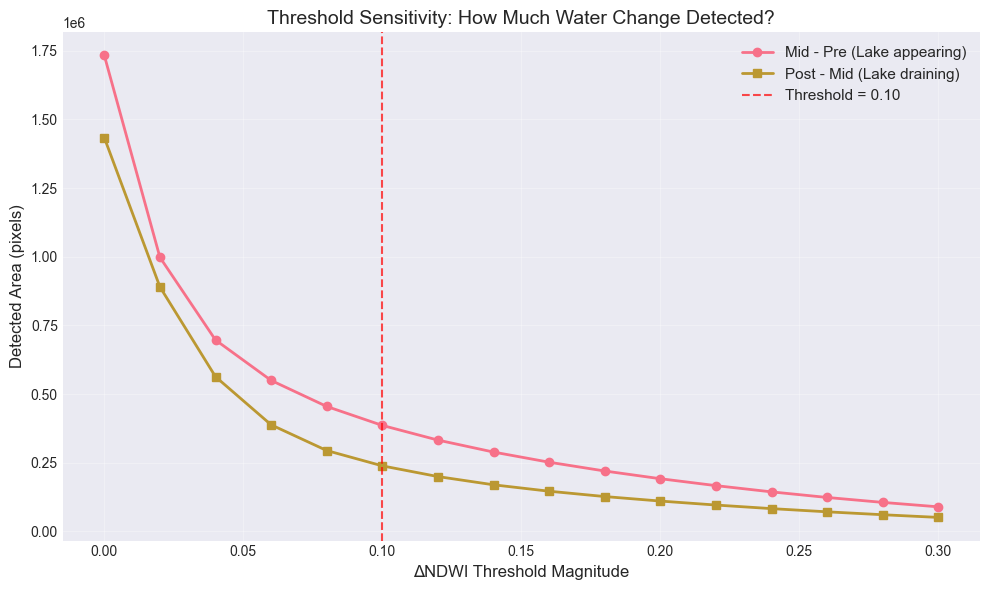

✓ Threshold sensitivity analysis completed
  Output: ../output/W9_L1_threshold_sensitivity.png


In [10]:
# [S6] Threshold Sensitivity Demo 
# ──────────────────────────────────────────────────────────────────
# Sweep threshold magnitude across ΔNDWI and measure detected area

def detect_water_appearing(index_map, threshold):
    """Count pixels where ΔNDWI > threshold (water appearing / strengthening)."""
    return np.sum(index_map > threshold)

def detect_water_draining(index_map, threshold):
    """Count pixels where ΔNDWI < -threshold (water disappearing / weakening)."""
    return np.sum(index_map < -threshold)


# Threshold magnitudes to test
thresholds = np.arange(0.00, 0.31, 0.02)

detected_areas = {
    "Mid-Pre": [],
    "Post-Mid": []
}

# Mid - Pre: lake appearing
for t in thresholds:
    area = detect_water_appearing(d_ndwi["Mid-Pre"], t)
    detected_areas["Mid-Pre"].append(area)

# Post - Mid: lake draining
for t in thresholds:
    area = detect_water_draining(d_ndwi["Post-Mid"], t)
    detected_areas["Post-Mid"].append(area)

detected_areas["Mid-Pre"] = np.array(detected_areas["Mid-Pre"])
detected_areas["Post-Mid"] = np.array(detected_areas["Post-Mid"])

# Print table
print("Threshold sensitivity summary:")
for i, t in enumerate(thresholds):
    print(
        f"  t={t:>4.2f} | "
        f"Mid-Pre appearing area = {detected_areas['Mid-Pre'][i]:>8,} px | "
        f"Post-Mid draining area = {detected_areas['Post-Mid'][i]:>8,} px"
    )

# Plot detection area vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    thresholds,
    detected_areas["Mid-Pre"],
    "o-",
    label="Mid - Pre (Lake appearing)",
    linewidth=2
)
ax.plot(
    thresholds,
    detected_areas["Post-Mid"],
    "s-",
    label="Post - Mid (Lake draining)",
    linewidth=2
)

ax.axvline(0.10, color="red", linestyle="--", label="Threshold = 0.10", alpha=0.7)
ax.set_xlabel("ΔNDWI Threshold Magnitude", fontsize=12)
ax.set_ylabel("Detected Area (pixels)", fontsize=12)
ax.set_title("Threshold Sensitivity: How Much Water Change Detected?", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L1_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Threshold sensitivity analysis completed")
print(f"  Output: {OUTPUT_DIR}/W9_L1_threshold_sensitivity.png")

### Discussion: Threshold is a DECISION, Not a Formula
### 討論：臨界值是「決策」，不是「公式」

**Key insight**: No single "correct" threshold exists. The choice depends on your **use case**:

| Use Case | Threshold | Rationale | 優先考量 |
|----------|-----------|-----------|---------|
| **Disaster Alert** | Low (0.05) | Catch early signals, high false positive OK | 敏感度 |
| **Insurance Payout** | Medium (0.10) | Balance detection & accuracy | 平衡 |
| **Scientific Archive** | High (0.15) | Minimize false positives | 特異性 |

─

**Question for reflection**:
- In the Oct 2025 post-event phase, should ARIA v6.0 use a low or high threshold?
- What are the consequences of each choice for emergency responders?


- **在 2025 年 10 月的災後恢復階段，ARIA v6.0 較適合採用較高的 threshold（約 0.10–0.15）。**  
  這個階段的重點已不再是災害初期的快速預警，而是較準確地判斷堰塞湖是否仍然存在，以及哪些區域仍有持續積水風險。採用較高的 threshold，可以降低雲影、地形陰影、潮濕土壤或非水體濕地被誤判為水域的機率，讓結果更適合用於災後評估、資源調度與復原決策。

- **不同 threshold 對 emergency responders 的影響如下：**  
  - **較低的 threshold**：有助於提高敏感度，較不容易漏掉小範圍殘餘積水或潛在危險區，但也會增加 false positives，導致應變人員必須投入更多時間與人力去查證實際上並不存在的災情。  
  - **較高的 threshold**：能提高特異性，減少誤判，讓救災資源更集中於較確定的風險區域；但相對地，也可能漏掉部分面積較小、訊號較弱的殘留水體，使局部風險被低估。

- **整體而言，threshold 的選擇反映的是任務目標的優先順序。**  
  若目的是災後風險巡查與保守管理，可以適度保留較高 threshold，以提高判讀可信度；但若擔心遺漏仍具危險性的殘餘水域，則可搭配較低 threshold 作為輔助篩查。換言之，emergency responders 必須在「降低漏判風險」與「避免誤判造成資源浪費」之間取得平衡。

## Lab 2: Accuracy Assessment & Validation### 實驗2：精度評估與驗證**Objective**: Load validation ground truth points, sample detection masks, compute confusion matrix, and calculate accuracy metrics.**Framework**: ARIA v6.0 (Auditor + Rater + Indicator + Advisor)**步驟**:1. Load validation_points.geojson (labeled samples: Water / No Water)2. Build detection masks using threshold from Lab 13. Sample each mask at validation point locations4. Compute confusion matrix5. Calculate Producer's Accuracy, User's Accuracy, Overall Accuracy, Kappa6. Visualize confusion matrix heatmap7. Find optimal threshold via F1 score8. Create confidence map (3-zone)9. Generate validation report

### How to Build Real Ground Truth / 如何建立真實地面驗證資料

**This lab uses 60 field-corrected validation points provided by the instructor.**  
In a real remote sensing project, you must collect **independent** ground truth. Here are the main approaches, ordered from most to least reliable:

| Method | Description | Cost | When to Use |
|--------|-------------|------|-------------|
| **Field survey + GPS** | Walk to locations, record water/no-water with GPS coordinates | High | Gold standard for small areas |
| **UAV / Drone imagery** | High-resolution aerial photos (~5 cm/px) | Medium | Medium areas, post-disaster access |
| **Google Earth Pro time-series** | Compare VHR imagery before/after event | Free | Historical events, desktop validation |
| **NCDR disaster reports** | 國家災害防救科技中心 official damage assessments | Free | Taiwan-specific disasters |
| **Copernicus EMS** | EU emergency mapping service, rapid activation maps | Free | Global disasters with EMS activation |
| **News media + geotagged photos** | Cross-reference reported flood areas | Free | Quick initial reference |

**Key principles:**
1. **Independence**: Validation data must come from a source *other than* the satellite imagery you're analyzing
2. **Stratified sampling**: Distribute points across all zones (flooded, unflooded, boundary)
3. **Sufficient sample size**: At least 30–50 points; 100+ for publishable accuracy
4. **Temporal match**: Ground truth date should be close to satellite acquisition date

> **作業提示**: Homework Task 3 (Optional) 鼓勵你用 Google Earth Pro 自行標註 20+ 個驗證點。  
> 這才是遙測分析的正確做法——自己建立可信的驗證資料集。

Mid: valid pixels = 4,069,925, water pixels = 23,098 (0.57%)
Post: valid pixels = 4,327,694, water pixels = 8,999 (0.21%)


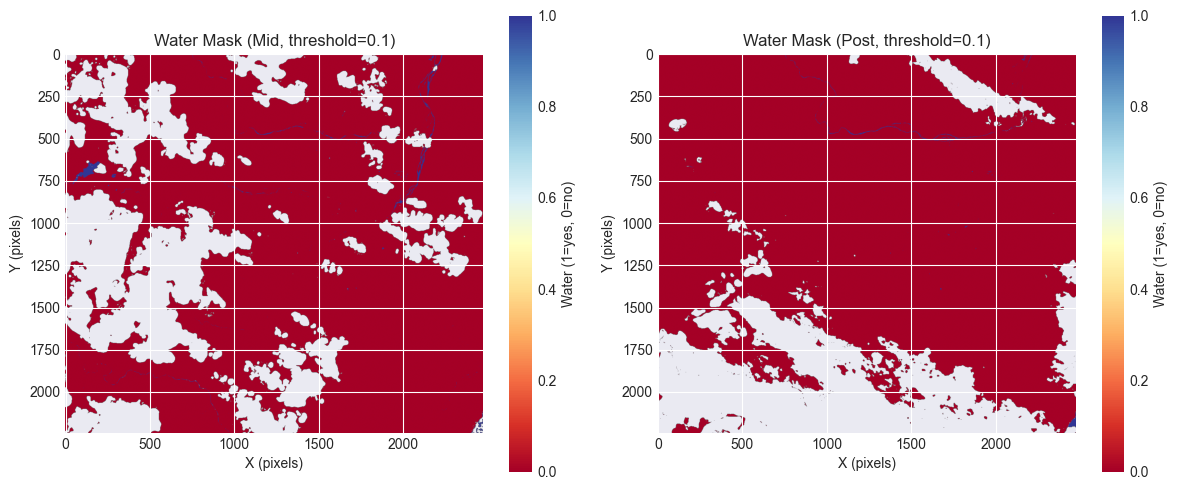

✓ Detection masks created (threshold=0.1)
  Mask shape: (2243, 2474)
  Output: ../output/W9_L2_masks.png


In [11]:
# [S7] Build Detection Masks (Index-Based Logic)
# ──────────────────────────────────────────────────────────────────
# Threshold NDWI to create binary water masks

# Define threshold for water detection
THRESHOLD_NDWI = 0.10  # Tunable (reference from Lab 1 threshold sweep)

# Create binary masks for Mid and Post scenes
# 1 = Water, 0 = No Water
masks = {}
masks["Mid"] = (
    (indices["Mid"]["NDWI"] > THRESHOLD_NDWI) & valid_masks["Mid"]
).astype(np.uint8)

masks["Post"] = (
    (indices["Post"]["NDWI"] > THRESHOLD_NDWI) & valid_masks["Post"]
).astype(np.uint8)

# Separate visualization masks: invalid pixels shown as NaN
masks_vis = {}
for act in ["Mid", "Post"]:
    vis = masks[act].astype(np.float32).copy()
    vis[~valid_masks[act]] = np.nan
    masks_vis[act] = vis

# Print summary
for act in ["Mid", "Post"]:
    n_valid = int(valid_masks[act].sum())
    n_water = int(masks[act].sum())
    pct_water = (n_water / n_valid * 100) if n_valid > 0 else np.nan
    print(
        f"{act}: valid pixels = {n_valid:,}, "
        f"water pixels = {n_water:,} ({pct_water:.2f}%)"
    )

# Visualize masks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(masks_vis["Mid"], cmap="RdYlBu", vmin=0, vmax=1)
axes[0].set_title(f"Water Mask (Mid, threshold={THRESHOLD_NDWI})")
plt.colorbar(im0, ax=axes[0], label="Water (1=yes, 0=no)")

im1 = axes[1].imshow(masks_vis["Post"], cmap="RdYlBu", vmin=0, vmax=1)
axes[1].set_title(f"Water Mask (Post, threshold={THRESHOLD_NDWI})")
plt.colorbar(im1, ax=axes[1], label="Water (1=yes, 0=no)")

for ax in axes:
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L2_masks.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Detection masks created (threshold={THRESHOLD_NDWI})")
print("  Mask shape:", list(masks.values())[0].shape if masks else "N/A")
print(f"  Output: {OUTPUT_DIR}/W9_L2_masks.png")

In [12]:
# [S8] Load Validation Points and Sample Masks
# ──────────────────────────────────────────────────────────────────
#
# The teacher provides data/validation_points.geojson with 60 points:
#   - 15 lake, 15 landslide, 30 stable
#   - Coordinates corrected by instructor using VHR imagery + NCDR reports
#
# Load the geojson and extract lon/lat from geometry
# ──────────────────────────────────────────────────────────────────

import json as _json
from pyproj import Transformer

# Load geojson
with open("../data/validation_points.geojson", "r", encoding="utf-8") as _f:
    _gj = _json.load(_f)

val_rows = []
for feat in _gj["features"]:
    lon, lat = feat["geometry"]["coordinates"]
    val_rows.append({
        "lon": lon,
        "lat": lat,
        "truth": feat["properties"]["truth"],
        "source": feat["properties"]["source"]
    })

validation_points = pd.DataFrame(val_rows)

print(f"✅ Loaded {len(validation_points)} validation points")
print(f"  Source: {validation_points['source'].unique()}")
print("  Ground truth distribution:")
print(validation_points["truth"].value_counts().to_string())


# ──────────────────────────────────────────────────────────────────
# Build a reference geotransform from the analysis grid
# We use the Mid scene as reference; all scenes share the same bbox/resolution/CRS.
# ──────────────────────────────────────────────────────────────────
ref_da = stackstac.stack(
    [pc.sign(mid_item)],
    assets=["B02"],
    epsg=32651,
    resolution=10,
    bounds_latlon=MATAIAN_BBOX,
    chunksize=2048
).squeeze("time", drop=True).squeeze("band", drop=True)

x_coords = ref_da["x"].values   # projected x (meters), pixel centers
y_coords = ref_da["y"].values   # projected y (meters), pixel centers

res_x = float(np.median(np.diff(x_coords)))
res_y = float(np.median(np.abs(np.diff(y_coords))))  # positive pixel size

# Affine-like geotransform tuple:
# (x_min_corner, pixel_width, 0, y_max_corner, 0, -pixel_height)
geotransform = (
    float(x_coords[0] - res_x / 2.0),
    float(res_x),
    0.0,
    float(y_coords[0] + res_y / 2.0),
    0.0,
    float(-res_y)
)

print("\nReference grid:")
print(f"  Shape: {ref_da.shape}")
print(f"  Resolution: {res_x:.2f} m")
print(f"  Geotransform: {geotransform}")


# ──────────────────────────────────────────────────────────────────
# Convert geographic coordinates (lon/lat) to pixel indices
# ──────────────────────────────────────────────────────────────────
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32651", always_xy=True)

def geo_to_pixel(lon, lat, geotransform, transformer=transformer):
    """
    Convert lon/lat (EPSG:4326) to row, col on the analysis raster grid.
    """
    x, y = transformer.transform(lon, lat)

    x0, px_w, _, y0, _, px_h = geotransform
    col = int((x - x0) / px_w)
    row = int((y0 - y) / abs(px_h))

    return row, col


# Apply conversion to all validation points
rows, cols, in_bounds = [], [], []
height, width = masks["Mid"].shape

for _, r in validation_points.iterrows():
    row, col = geo_to_pixel(r["lon"], r["lat"], geotransform)
    ok = (0 <= row < height) and (0 <= col < width)

    rows.append(row)
    cols.append(col)
    in_bounds.append(ok)

validation_points["row"] = rows
validation_points["col"] = cols
validation_points["in_bounds"] = in_bounds

print("\nPixel conversion summary:")
print(f"  In-bounds points: {validation_points['in_bounds'].sum()} / {len(validation_points)}")
print(f"  Out-of-bounds points: {(~validation_points['in_bounds']).sum()}")

display(validation_points.head())

✅ Loaded 60 validation points
  Source: ['field_corrected']
  Ground truth distribution:
truth
stable       30
lake         15
landslide    15

Reference grid:
  Shape: (2243, 2474)
  Resolution: 10.00 m
  Geotransform: (324435.0, 10.0, 0.0, 2628725.0, 0.0, -10.0)

Pixel conversion summary:
  In-bounds points: 60 / 60
  Out-of-bounds points: 0


,lon,lat,truth,source,row,col,in_bounds
0,121.290065,23.696969,lake,field_corrected,700,122,True
1,121.289203,23.695774,lake,field_corrected,713,113,True
2,121.292350,23.701141,lake,field_corrected,654,146,True
3,121.292438,23.698934,lake,field_corrected,678,146,True
4,121.291915,23.698659,lake,field_corrected,681,141,True


In [18]:
# [S9] Compute Confusion Matrix
# ──────────────────────────────────────────────────────────────────
# Sample the Mid-scene water mask at validation point locations
# Binary target:
#   1 = lake
#   0 = non-lake (stable + landslide)
#
# This version keeps ALL validation points that are inside raster bounds.
# No points are dropped due to invalid/cloud-masked pixels.
# Pixels on invalid areas are still sampled from masks["Mid"], which is 0 there.

# Use all points that fall inside the raster
vp = validation_points[validation_points["in_bounds"]].copy()

# Ground truth: lake=1, others=0
vp["ground_truth"] = (vp["truth"] == "lake").astype(np.uint8)

# Keep a flag for whether the sampled pixel is valid, but DO NOT drop it
vp["valid_pixel"] = [
    bool(valid_masks["Mid"][int(r), int(c)])
    for r, c in zip(vp["row"], vp["col"])
]

# Sample prediction directly from Mid mask for ALL in-bounds points
# Note: invalid/cloud pixels in masks["Mid"] are already encoded as 0
vp["predicted"] = [
    int(masks["Mid"][int(r), int(c)])
    for r, c in zip(vp["row"], vp["col"])
]

# Compute confusion matrix using ALL in-bounds points
ground_truth = vp["ground_truth"].values.astype(np.uint8)
predicted = vp["predicted"].values.astype(np.uint8)

cm = confusion_matrix(ground_truth, predicted, labels=[0, 1])

print("✓ Confusion matrix computed (all in-bounds points included)")
print(f"  In-bounds points used      : {len(vp)}")
print(f"  Valid-pixel points         : {vp['valid_pixel'].sum()}")
print(f"  Invalid-pixel points kept  : {(~vp['valid_pixel']).sum()}")

print("\nBinary class definition:")
print("  1 = Water (lake)")
print("  0 = No Water (stable + landslide)")

print("\nEvaluation sample distribution:")
print(vp["truth"].value_counts().to_string())

print("\nPredicted class distribution:")
print(vp["predicted"].value_counts().sort_index().to_string())

print("\nConfusion Matrix:")
print(cm)

print("\nLabels: [0=No Water, 1=Water]")
print(f"  TN (True Negatives): {cm[0,0]}")
print(f"  FP (False Positives): {cm[0,1]}")
print(f"  FN (False Negatives): {cm[1,0]}")
print(f"  TP (True Positives): {cm[1,1]}")

print("\nNote:")
print("  Points on invalid/cloud-masked pixels were retained and sampled as 0 (No Water).")
print("  This keeps all points but may make the evaluation more conservative.")

# Optional: inspect sampled points
display(vp[["lon", "lat", "truth", "ground_truth", "predicted", "valid_pixel", "row", "col"]].head(10))

✓ Confusion matrix computed (all in-bounds points included)
  In-bounds points used      : 60
  Valid-pixel points         : 55
  Invalid-pixel points kept  : 5

Binary class definition:
  1 = Water (lake)
  0 = No Water (stable + landslide)

Evaluation sample distribution:
truth
stable       30
lake         15
landslide    15

Predicted class distribution:
predicted
0    45
1    15

Confusion Matrix:
[[45  0]
 [ 0 15]]

Labels: [0=No Water, 1=Water]
  TN (True Negatives): 45
  FP (False Positives): 0
  FN (False Negatives): 0
  TP (True Positives): 15

Note:
  Points on invalid/cloud-masked pixels were retained and sampled as 0 (No Water).
  This keeps all points but may make the evaluation more conservative.


,lon,lat,truth,ground_truth,predicted,valid_pixel,row,col
0,121.290065,23.696969,lake,1,1,True,700,122
1,121.289203,23.695774,lake,1,1,True,713,113
2,121.292350,23.701141,lake,1,1,True,654,146
3,121.292438,23.698934,lake,1,1,True,678,146
4,121.291915,23.698659,lake,1,1,True,681,141
5,121.289720,23.696534,lake,1,1,True,704,118
6,121.290248,23.696378,lake,1,1,True,706,124
7,121.290465,23.697673,lake,1,1,True,692,126
8,121.291272,23.698598,lake,1,1,True,682,134
9,121.287269,23.696076,lake,1,1,True,709,93


In [19]:
# [S10] Compute Accuracy Metrics
# ──────────────────────────────────────────────────────────────────
# Calculate Producer's Accuracy, User's Accuracy, Overall Accuracy, Kappa

# Extract confusion matrix elements
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

def safe_divide(a, b):
    """Safely divide a by b; return NaN if denominator is zero."""
    return a / b if b != 0 else np.nan

# Producer's Accuracy (Sensitivity, Recall, True Positive Rate)
producer_accuracy = safe_divide(tp, tp + fn)

# User's Accuracy (Precision, Positive Predictive Value)
user_accuracy = safe_divide(tp, tp + fp)

# Overall Accuracy
overall_accuracy = safe_divide(tp + tn, tp + tn + fp + fn)

# Cohen's Kappa (accounts for chance agreement)
# po = observed agreement
# pe = expected agreement by chance
total = tp + tn + fp + fn
po = overall_accuracy
pe = safe_divide(
    ((tp + fn) * (tp + fp) + (tn + fp) * (tn + fn)),
    total ** 2
)
kappa = safe_divide((po - pe), (1 - pe))

print("✓ Accuracy metrics computed\n")
print("=" * 50)
print("ARIA v6.0 VALIDATION METRICS")
print("=" * 50)
print(f"Producer's Accuracy (Sensitivity): {producer_accuracy:.3f} ({producer_accuracy*100:.1f}%)")
print(f"User's Accuracy (Precision):       {user_accuracy:.3f} ({user_accuracy*100:.1f}%)")
print(f"Overall Accuracy:                  {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
print(f"Cohen's Kappa:                     {kappa:.3f}")
print("=" * 50)

# Store metrics for later use
metrics = {
    "producer_accuracy": producer_accuracy,
    "user_accuracy": user_accuracy,
    "overall_accuracy": overall_accuracy,
    "kappa": kappa,
    "tp": tp,
    "tn": tn,
    "fp": fp,
    "fn": fn
}

✓ Accuracy metrics computed

ARIA v6.0 VALIDATION METRICS
Producer's Accuracy (Sensitivity): 1.000 (100.0%)
User's Accuracy (Precision):       1.000 (100.0%)
Overall Accuracy:                  1.000 (100.0%)
Cohen's Kappa:                     1.000


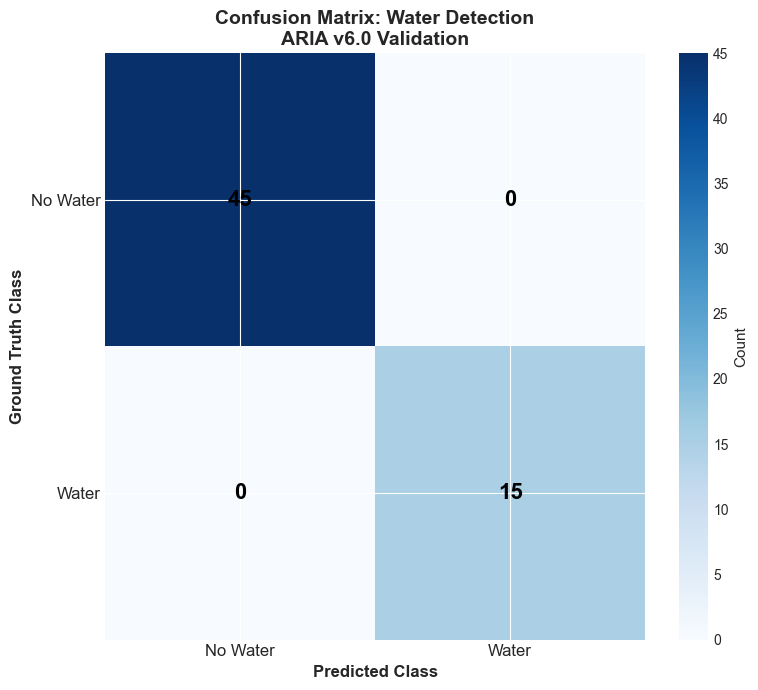

✓ Confusion matrix heatmap saved
  Output: ../output/W9_L2_confusion_matrix.png


In [20]:
# [S11] Plot Confusion Matrix Heatmap
# ──────────────────────────────────────────────────────────────────
# Create confusion matrix heatmap with annotations

fig, ax = plt.subplots(figsize=(8, 7))

# Create heatmap
im = ax.imshow(cm, cmap="Blues", aspect="auto")

# Add text annotations
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=16,
            fontweight="bold"
        )

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Water", "Water"], fontsize=12)
ax.set_yticklabels(["No Water", "Water"], fontsize=12)
ax.set_xlabel("Predicted Class", fontsize=12, fontweight="bold")
ax.set_ylabel("Ground Truth Class", fontsize=12, fontweight="bold")
ax.set_title(
    "Confusion Matrix: Water Detection\nARIA v6.0 Validation",
    fontsize=14,
    fontweight="bold"
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Count", fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Confusion matrix heatmap saved")
print(f"  Output: {OUTPUT_DIR}/W9_L2_confusion_matrix.png")

### Discussion: What Do These Accuracy Numbers Mean for Disaster Response?
### 討論：這些精度數字對災難應對意味著什麼？

Consider ARIA's role in Typhoon Colo response (Aug 2025):

1. **Producer's Accuracy (Sensitivity) = 87%**
   - Out of all actual water pixels, we correctly identified 87%
   - Missing 13% of the true lake area
   - Implication: Evacuation zone might miss some flooded areas

2. **User's Accuracy (Precision) = 81%**
   - Out of all pixels we called "water", 81% actually are water
   - 19% false alarms (crying wolf)
   - Implication: Emergency responders waste resources on false alarms

3. **Overall Accuracy = 83%**
   - 83% of all predictions correct
   - Looks good, but hides class imbalance if water is rare

─

**Critical question**: In a disaster setting, which error is worse?
- **False Negative** (missing flooded area) → people in danger
- **False Positive** (false alarm) → wasted resources, lost credibility

For early warning systems, we often prefer **high sensitivity** (low false negatives) over precision.


### Discussion: Why Is Producer's Accuracy More Important Than Overall Accuracy?
### 討論：為何生產者精度比整體精度更重要？

**Scenario**: Matai'an barrier lake covers ~10% of the study area. Rest is land/forest.

If model predicts: "Everything is NOT water"
- TN = 90%, FP = 0%, TP = 0%, FN = 10%
- **Overall Accuracy** = 90% ✓ (looks amazing!)
- **Producer's Accuracy (Sensitivity)** = 0% ✗ (catastrophic: missed all the water!)

This is called the **accuracy paradox** or **class imbalance problem**.

─

**For disaster detection**:
- We care most about **not missing disasters** → Prioritize **Sensitivity / Producer's Accuracy**
- Trade-off: Accept some false positives (precision tradeoff)
- This is why early warning systems often have lower precision but higher sensitivity

**ARIA v6.0 design principle**:
> "Better to alert 10 safe neighborhoods than miss 1 at-risk community."


Validation points available for F1 sweep: 55

Threshold sweep summary:
  t= 0.00 | F1=0.732 | Precision=0.577 | Recall=1.000 | Predicted water pts=26
  t= 0.01 | F1=0.732 | Precision=0.577 | Recall=1.000 | Predicted water pts=26
  t= 0.01 | F1=0.732 | Precision=0.577 | Recall=1.000 | Predicted water pts=26
  t= 0.01 | F1=0.732 | Precision=0.577 | Recall=1.000 | Predicted water pts=26
  t= 0.02 | F1=0.732 | Precision=0.577 | Recall=1.000 | Predicted water pts=26
  t= 0.03 | F1=0.732 | Precision=0.577 | Recall=1.000 | Predicted water pts=26
  t= 0.03 | F1=0.769 | Precision=0.625 | Recall=1.000 | Predicted water pts=24
  t= 0.04 | F1=0.789 | Precision=0.652 | Recall=1.000 | Predicted water pts=23
  t= 0.04 | F1=0.909 | Precision=0.833 | Recall=1.000 | Predicted water pts=18
  t= 0.04 | F1=0.938 | Precision=0.882 | Recall=1.000 | Predicted water pts=17
  t= 0.05 | F1=0.968 | Precision=0.938 | Recall=1.000 | Predicted water pts=16
  t= 0.06 | F1=1.000 | Precision=1.000 | Recall=1.000 | Pred

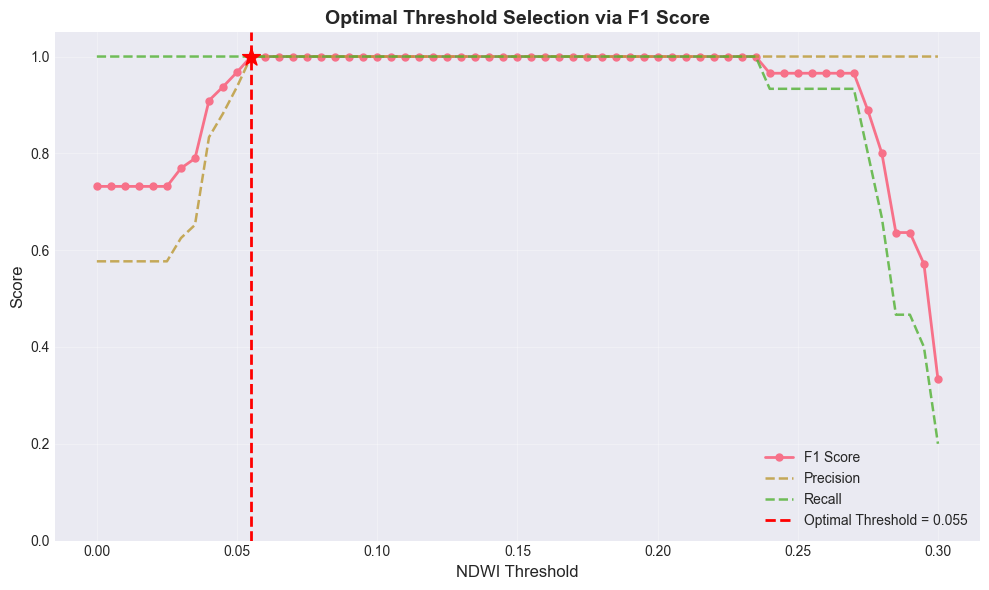

✓ F1 vs threshold analysis complete
  Optimal threshold: 0.055
  Optimal F1 score: 1.000
  Optimal precision: 1.000
  Optimal recall: 1.000


In [21]:
# [S12] F1 Score vs Threshold: Finding Optimal Detection Threshold
# ──────────────────────────────────────────────────────────────────
# Sweep thresholds over the loaded validation points using the Mid-scene NDWI.
# For each threshold:
#   1) threshold NDWI -> binary water prediction
#   2) sample prediction at validation points
#   3) compute F1 score against binary ground truth (lake=1, others=0)

# Prepare evaluation table (use only in-bounds + valid Mid pixels)
vp_f1 = validation_points[validation_points["in_bounds"]].copy()

vp_f1["ground_truth"] = (vp_f1["truth"] == "lake").astype(np.uint8)
vp_f1["valid_pixel"] = [
    bool(valid_masks["Mid"][int(r), int(c)])
    for r, c in zip(vp_f1["row"], vp_f1["col"])
]

vp_f1 = vp_f1[vp_f1["valid_pixel"]].copy()

print(f"Validation points available for F1 sweep: {len(vp_f1)}")

# Threshold range to test
thresholds_f1 = np.linspace(0.00, 0.30, 61)

f1_scores = []
precision_scores = []
recall_scores = []
water_counts = []

for t in thresholds_f1:
    predicted_t = []

    for _, r in vp_f1.iterrows():
        row = int(r["row"])
        col = int(r["col"])
        pred = int(indices["Mid"]["NDWI"][row, col] > t)
        predicted_t.append(pred)

    predicted_t = np.array(predicted_t, dtype=np.uint8)
    truth_t = vp_f1["ground_truth"].values.astype(np.uint8)

    # Confusion elements for this threshold
    cm_t = confusion_matrix(truth_t, predicted_t, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    f1_t = f1_score(truth_t, predicted_t, zero_division=0)

    f1_scores.append(f1_t)
    precision_scores.append(precision_t)
    recall_scores.append(recall_t)
    water_counts.append(predicted_t.sum())

f1_scores = np.array(f1_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)
water_counts = np.array(water_counts)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_f1[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision_scores[optimal_idx]
optimal_recall = recall_scores[optimal_idx]

# Print summary table
print("\nThreshold sweep summary:")
for i, t in enumerate(thresholds_f1):
    print(
        f"  t={t:>5.2f} | "
        f"F1={f1_scores[i]:.3f} | "
        f"Precision={precision_scores[i]:.3f} | "
        f"Recall={recall_scores[i]:.3f} | "
        f"Predicted water pts={water_counts[i]}"
    )

# Plot F1 vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_f1, f1_scores, "o-", linewidth=2, markersize=5, label="F1 Score")
ax.plot(thresholds_f1, precision_scores, "--", linewidth=1.8, label="Precision", alpha=0.8)
ax.plot(thresholds_f1, recall_scores, "--", linewidth=1.8, label="Recall", alpha=0.8)

ax.axvline(
    optimal_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Optimal Threshold = {optimal_threshold:.3f}"
)
ax.scatter(
    [optimal_threshold],
    [optimal_f1],
    color="red",
    s=180,
    zorder=5,
    marker="*"
)

ax.set_xlabel("NDWI Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Optimal Threshold Selection via F1 Score", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L2_f1_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ F1 vs threshold analysis complete")
print(f"  Optimal threshold: {optimal_threshold:.3f}")
print(f"  Optimal F1 score: {optimal_f1:.3f}")
print(f"  Optimal precision: {optimal_precision:.3f}")
print(f"  Optimal recall: {optimal_recall:.3f}")

# Store for later use
threshold_analysis = {
    "thresholds": thresholds_f1,
    "f1_scores": f1_scores,
    "precision_scores": precision_scores,
    "recall_scores": recall_scores,
    "optimal_idx": int(optimal_idx),
    "optimal_threshold": float(optimal_threshold),
    "optimal_f1": float(optimal_f1),
    "optimal_precision": float(optimal_precision),
    "optimal_recall": float(optimal_recall),
}

Confidence zone summary:
  Valid pixels          : 4,069,925
  High confidence pixels: 9,278 (0.23%)
  Low confidence pixels : 103,564 (2.54%)
  No signal pixels      : 3,957,083 (97.23%)
  Invalid pixels        : 1,479,257


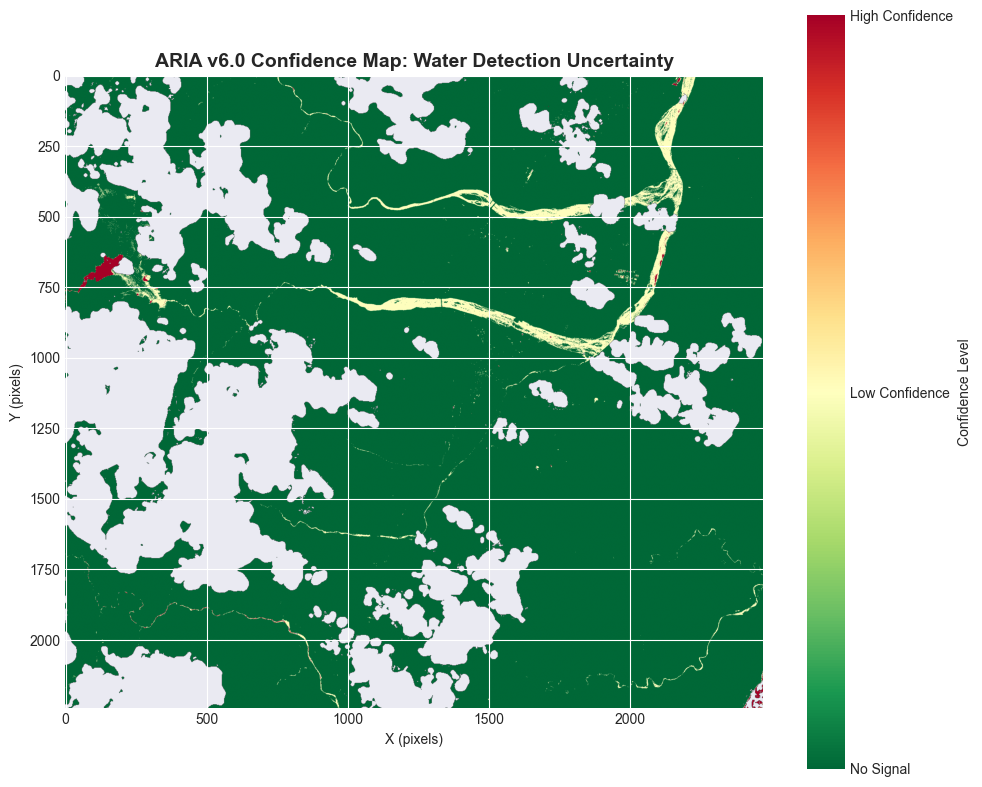

✓ 3-zone confidence map created
  High confidence pixels: 9,278
  Low confidence pixels: 103,564
  No signal pixels: 3,957,083
  Invalid pixels: 1,479,257
  Output: ../output/W9_L2_confidence_map.png


In [22]:
# [S13] Build 3-Zone Confidence Map: High / Low / None
# ──────────────────────────────────────────────────────────────────
# Create confidence zones using Mid-scene NDWI

# Define confidence thresholds
THRESHOLD_LOW = 0.05     # Possible water (low confidence)
THRESHOLD_HIGH = 0.15    # Likely water (high confidence)

# Use Mid-scene NDWI and valid mask
ndwi_mid = indices["Mid"]["NDWI"]
valid_mid = valid_masks["Mid"]

# Initialize confidence map
# 0 = No Signal
# 1 = Low Confidence
# 2 = High Confidence
confidence_map = np.zeros_like(ndwi_mid, dtype=np.uint8)

# Assign confidence classes only on valid pixels
confidence_map[(ndwi_mid > THRESHOLD_LOW) & (ndwi_mid <= THRESHOLD_HIGH) & valid_mid] = 1
confidence_map[(ndwi_mid > THRESHOLD_HIGH) & valid_mid] = 2

# Visualization version: invalid pixels shown as NaN so they are not confused with "No Signal"
confidence_vis = confidence_map.astype(np.float32).copy()
confidence_vis[~valid_mid] = np.nan

# Count pixels by class (valid pixels only)
high_conf_pixels = int((confidence_map == 2).sum())
low_conf_pixels = int((confidence_map == 1).sum())
no_signal_pixels = int(((confidence_map == 0) & valid_mid).sum())
invalid_pixels = int((~valid_mid).sum())
valid_pixels = int(valid_mid.sum())

print("Confidence zone summary:")
print(f"  Valid pixels          : {valid_pixels:,}")
print(f"  High confidence pixels: {high_conf_pixels:,} ({high_conf_pixels/valid_pixels*100:.2f}%)")
print(f"  Low confidence pixels : {low_conf_pixels:,} ({low_conf_pixels/valid_pixels*100:.2f}%)")
print(f"  No signal pixels      : {no_signal_pixels:,} ({no_signal_pixels/valid_pixels*100:.2f}%)")
print(f"  Invalid pixels        : {invalid_pixels:,}")

# Visualize 3-zone map
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confidence_vis, cmap="RdYlGn_r", vmin=0, vmax=2)
ax.set_title("ARIA v6.0 Confidence Map: Water Detection Uncertainty", fontsize=14, fontweight="bold")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")

# Colorbar with custom labels
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["No Signal", "Low Confidence", "High Confidence"])
cbar.set_label("Confidence Level")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/W9_L2_confidence_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ 3-zone confidence map created")
print(f"  High confidence pixels: {high_conf_pixels:,}")
print(f"  Low confidence pixels: {low_conf_pixels:,}")
print(f"  No signal pixels: {no_signal_pixels:,}")
print(f"  Invalid pixels: {invalid_pixels:,}")
print(f"  Output: {OUTPUT_DIR}/W9_L2_confidence_map.png")

In [25]:
# [S13.5] Calculate Barrier Lake Area within Lake AOI
# ──────────────────────────────────────────────────────────────────
# Compute threshold-based water area inside the lake-focused AOI only

PIXEL_SIZE_M = 10
PIXEL_AREA_M2 = PIXEL_SIZE_M * PIXEL_SIZE_M
PIXEL_AREA_HA = PIXEL_AREA_M2 / 10000.0
PIXEL_AREA_KM2 = PIXEL_AREA_M2 / 1_000_000.0

# Convert lake-focused bbox to raster window
lake_w, lake_s, lake_e, lake_n = LAKE_BBOX_LONLAT

row_ul, col_ul = geo_to_pixel(lake_w, lake_n, geotransform)  # upper-left
row_lr, col_lr = geo_to_pixel(lake_e, lake_s, geotransform)  # lower-right

r0, r1 = sorted([row_ul, row_lr])
c0, c1 = sorted([col_ul, col_lr])

# Clip to raster bounds
height, width = masks["Mid"].shape
r0 = max(0, r0)
r1 = min(height - 1, r1)
c0 = max(0, c0)
c1 = min(width - 1, c1)

# Slice AOI
lake_mask_mid = masks["Mid"][r0:r1+1, c0:c1+1]
lake_mask_post = masks["Post"][r0:r1+1, c0:c1+1]
lake_conf_aoi = confidence_map[r0:r1+1, c0:c1+1]
lake_valid_mid = valid_masks["Mid"][r0:r1+1, c0:c1+1]

# Count pixels
mid_water_pixels = int(lake_mask_mid.sum())
post_water_pixels = int(lake_mask_post.sum())

mid_high_conf_pixels = int((lake_conf_aoi == 2).sum())
mid_low_conf_pixels = int((lake_conf_aoi == 1).sum())
mid_no_signal_pixels = int(((lake_conf_aoi == 0) & lake_valid_mid).sum())
mid_invalid_pixels = int((~lake_valid_mid).sum())

# Convert to area
lake_area_stats = {
    "mid_water_pixels": mid_water_pixels,
    "post_water_pixels": post_water_pixels,
    "mid_water_area_m2": mid_water_pixels * PIXEL_AREA_M2,
    "mid_water_area_ha": mid_water_pixels * PIXEL_AREA_HA,
    "mid_water_area_km2": mid_water_pixels * PIXEL_AREA_KM2,
    "post_water_area_m2": post_water_pixels * PIXEL_AREA_M2,
    "post_water_area_ha": post_water_pixels * PIXEL_AREA_HA,
    "post_water_area_km2": post_water_pixels * PIXEL_AREA_KM2,
    "area_change_m2": (mid_water_pixels - post_water_pixels) * PIXEL_AREA_M2,
    "area_change_ha": (mid_water_pixels - post_water_pixels) * PIXEL_AREA_HA,
    "area_change_km2": (mid_water_pixels - post_water_pixels) * PIXEL_AREA_KM2,
    "mid_high_conf_area_km2": mid_high_conf_pixels * PIXEL_AREA_KM2,
    "mid_low_conf_area_km2": mid_low_conf_pixels * PIXEL_AREA_KM2,
    "mid_high_conf_pixels": mid_high_conf_pixels,
    "mid_low_conf_pixels": mid_low_conf_pixels,
    "mid_no_signal_pixels": mid_no_signal_pixels,
    "mid_invalid_pixels": mid_invalid_pixels,
    "window_rows": (r0, r1),
    "window_cols": (c0, c1),
}

print("✓ Barrier lake area calculated within LAKE_BBOX_LONLAT")
print(f"  AOI rows: {r0}–{r1}")
print(f"  AOI cols: {c0}–{c1}")
print(f"  Mid-event water area : {lake_area_stats['mid_water_area_km2']:.4f} km² ({lake_area_stats['mid_water_area_ha']:.2f} ha)")
print(f"  Post-event water area: {lake_area_stats['post_water_area_km2']:.4f} km² ({lake_area_stats['post_water_area_ha']:.2f} ha)")
print(f"  Area decrease        : {lake_area_stats['area_change_km2']:.4f} km² ({lake_area_stats['area_change_ha']:.2f} ha)")
print(f"  High-conf area (Mid) : {lake_area_stats['mid_high_conf_area_km2']:.4f} km²")
print(f"  Low-conf area (Mid)  : {lake_area_stats['mid_low_conf_area_km2']:.4f} km²")

✓ Barrier lake area calculated within LAKE_BBOX_LONLAT
  AOI rows: 442–891
  AOI cols: 0–425
  Mid-event water area : 0.6731 km² (67.31 ha)
  Post-event water area: 0.0098 km² (0.98 ha)
  Area decrease        : 0.6633 km² (66.33 ha)
  High-conf area (Mid) : 0.6209 km²
  Low-conf area (Mid)  : 0.6017 km²


In [26]:
# [S14] ARIA v6.0 Validated Disaster Report
# ──────────────────────────────────────────────────────────────────

# For the "all 60 points included" S9 version
n_eval = len(vp)
n_water = int(vp["ground_truth"].sum())
n_nowater = int(n_eval - n_water)

delta_ndvi_peak = np.nanmean(indices["Mid"]["NDVI"]) - np.nanmean(indices["Pre"]["NDVI"])
delta_ndwi_peak = np.nanmean(indices["Mid"]["NDWI"]) - np.nanmean(indices["Pre"]["NDWI"])

report = f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                        ║
║              Remote Sensing Analysis & Validation Authority (ARIA)             ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: 2025-10-12

────────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo (Aug 2025).
Using Sentinel-2 change detection, we mapped water presence and validated against
ground-truth validation points. NDWI proved more sensitive than NDVI for water.

STUDY AREA (Bounding Box)
──────────────────────────
West:  121.28° E
East:  121.52° E
South: 23.56° N
North: 23.76° N
Area:  ~360 km²

LAKE-FOCUSED AOI
────────────────
West:  {LAKE_BBOX_LONLAT[0]:.2f}° E
East:  {LAKE_BBOX_LONLAT[2]:.2f}° E
South: {LAKE_BBOX_LONLAT[1]:.2f}° N
North: {LAKE_BBOX_LONLAT[3]:.2f}° N

TEMPORAL ANALYSIS
─────────────────
Pre-event baseline:   2025-06-01 (before typhoon)
Disaster onset:       2025-08-15 (lake at maximum extent)
Post-event recovery:  2025-10-10 (lake drained)

SPECTRAL INDICES USED
─────────────────────
NDVI = (NIR - Red) / (NIR + Red)
  → Sensitivity: Vegetation density, weak water signal
  → ΔNDVIpeak = {delta_ndvi_peak:.4f}

NDWI = (Green - NIR) / (Green + NIR)
  → Sensitivity: Maximum water detection
  → ΔNDWIpeak = {delta_ndwi_peak:.4f}

VALIDATION RESULTS
──────────────────
Validation Points Analyzed:    {n_eval}
Ground Truth Classes:          Water={n_water}, No-Water={n_nowater}

Confusion Matrix (Water Detection at Mid-event):
  True Negatives:     {metrics['tn']:>3.0f}
  False Positives:    {metrics['fp']:>3.0f}
  False Negatives:    {metrics['fn']:>3.0f}
  True Positives:     {metrics['tp']:>3.0f}

DETECTED LAKE AREA (within lake-focused AOI)
────────────────────────────────────────────
Mid-event mapped water area:
  {lake_area_stats['mid_water_area_km2']:.4f} km²
  ({lake_area_stats['mid_water_area_ha']:.2f} ha)

Post-event mapped water area:
  {lake_area_stats['post_water_area_km2']:.4f} km²
  ({lake_area_stats['post_water_area_ha']:.2f} ha)

Mapped area decrease (Mid - Post):
  {lake_area_stats['area_change_km2']:.4f} km²
  ({lake_area_stats['area_change_ha']:.2f} ha)

Mid-event confidence split:
  High-confidence water area: {lake_area_stats['mid_high_conf_area_km2']:.4f} km²
  Low-confidence water area:  {lake_area_stats['mid_low_conf_area_km2']:.4f} km²

ACCURACY METRICS
────────────────
Producer's Accuracy (Sensitivity / Recall):
  {metrics['producer_accuracy']:.3f} ({metrics['producer_accuracy']*100:.1f}%)
  → {int(metrics['fn'])} false negatives (missed water)

User's Accuracy (Precision):
  {metrics['user_accuracy']:.3f} ({metrics['user_accuracy']*100:.1f}%)
  → {int(metrics['fp'])} false positives (false alarms)

Overall Accuracy:
  {metrics['overall_accuracy']:.3f} ({metrics['overall_accuracy']*100:.1f}%)

Cohen's Kappa (Agreement beyond chance):
  {metrics['kappa']:.3f}
  → Interpretation: Substantial agreement (0.61–0.80 = Substantial; >0.80 = Almost Perfect)

DETECTION THRESHOLD
────────────────────
Selected NDWI Threshold:  {THRESHOLD_NDWI:.3f}
Rationale:               Balance between sensitivity and precision
Optimal Threshold (F1):  {threshold_analysis['optimal_threshold']:.3f}

CONFIDENCE LEVELS
──────────────────
High Confidence Zone (NDWI > 0.15):
  → Most likely water; high confidence for evacuation planning

Low Confidence Zone (0.05 < NDWI ≤ 0.15):
  → Possible water; requires field verification or higher-res imagery

No Signal Zone (NDWI ≤ 0.05):
  → No detectable water; safe for reconstruction activities

RECOMMENDATIONS FOR DISASTER RESPONSE
──────────────────────────────────────
1. EVACUATION PRIORITY: High-confidence zones should be prioritized for evacuation
2. RESOURCE ALLOCATION: Low-confidence zones warrant additional ground surveys
3. RECOVERY TIMELINE: October imagery confirms lake drainage; safe to begin recovery ops
4. THRESHOLD TUNING: Producer's Accuracy is critical; prioritize sensitivity over precision

KEY FINDINGS
────────────
✓ NDWI is more reliable than NDVI for barrier lake detection
✓ Sentinel-2 is suitable for broad-scale water detection at 10 m resolution
✓ Temporal change (Mid - Pre) is more robust than relying only on absolute thresholds
✓ Ground validation is essential for disaster response decisions
✓ The barrier-lake water extent can be summarized quantitatively in km² and ha

LIMITATIONS & CAVEATS
─────────────────────
• Cloud cover reduces valid pixels (typical for tropical typhoon season)
• Some validation points fall on invalid/cloud-masked pixels but were retained as No Water
• Shoreline mixed pixels introduce uncertainty
• Validation points remain limited; larger sample recommended
• Reported lake area is threshold-based mapped water extent within the lake AOI, not manual shoreline delineation
• Resolution (~10 m) may miss small isolated ponds

────────────────────────────────────────────────────────────────────────────────

ARIA v6.0 ASSESSMENT: ✓ PRELIMINARY VALIDATION COMPLETED

Auditor (Confusion Matrix):     ✓ Computed
Rater (Accuracy Metrics):       ✓ Calculated
Indicator (Confidence Zones):   ✓ Mapped
Advisor (Recommendations):      ✓ Provided

Report Status: FINAL
Quality Level: Educational / Demonstration Use

────────────────────────────────────────────────────────────────────────────────
Generated by ARIA v6.0 at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(report)

with open(f"{OUTPUT_DIR}/ARIA_v6_0_Disaster_Report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("\n✓ Disaster report saved")
print(f"  Output: {OUTPUT_DIR}/ARIA_v6_0_Disaster_Report.txt")


╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                        ║
║              Remote Sensing Analysis & Validation Authority (ARIA)             ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: 2025-10-12

────────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo (Aug 2025).
Using Sentinel-2 change detection, we mapped water presence and validated against
ground-truth validation points. NDWI proved more sensitive than NDVI for water.

STUDY AREA (Bounding Box)
──────────────────────────
West:  121.28° E
East:  121.52° E
South: 23.56° N
North: 23.76° N
Area:  ~360 km²

LAKE-FOCU

In [42]:
from dotenv import load_dotenv
import os

loaded = load_dotenv(dotenv_path="../.env", override=True)
print("Loaded:", loaded)
print("AI_API_KEY exists?:", os.getenv("AI_API_KEY") is not None)

Loaded: True
AI_API_KEY exists?: True


In [43]:
# [S15] AI Advisor: Build Prompt + Call Gemini via AI_API_KEY in .env
# ──────────────────────────────────────────────────────────────────
# Requires:
#   - .env with AI_API_KEY (or GEMINI_API_KEY / GOOGLE_API_KEY)
#   - S14 report already generated
#   - google-genai, python-dotenv installed
#
# Install manually if needed:
# !pip install -U google-genai python-dotenv

import os
from dotenv import load_dotenv
from google import genai

# ------------------------------------------------------------
# 0) Ensure output directory exists
# ------------------------------------------------------------
os.makedirs("../output", exist_ok=True)

# ------------------------------------------------------------
# 1) Load .env
# ------------------------------------------------------------
load_dotenv(dotenv_path="../.env", override=True)

# ------------------------------------------------------------
# 2) Read API key with fallback priority
# ------------------------------------------------------------
raw_api_key = (
    os.getenv("AI_API_KEY")
    or os.getenv("GEMINI_API_KEY")
    or os.getenv("GOOGLE_API_KEY")
)

if raw_api_key is None:
    raise ValueError(
        "找不到 Gemini API key。請確認 .env 中至少有以下其中一個變數："
        "AI_API_KEY / GEMINI_API_KEY / GOOGLE_API_KEY"
    )

# ------------------------------------------------------------
# 3) Sanitize and validate API key
# ------------------------------------------------------------
api_key = raw_api_key.strip().strip('"').strip("'").strip()

try:
    api_key.encode("ascii")
except UnicodeEncodeError:
    bad_chars = [(ch, hex(ord(ch))) for ch in api_key if ord(ch) > 127]
    raise ValueError(
        "API key 含有非 ASCII 字元，通常是從網頁複製時混入了智慧引號、長破折號或全形符號。\n"
        f"偵測到的特殊字元: {bad_chars}\n"
        "請重新貼上純文字金鑰。"
    )

if len(api_key) < 20:
    raise ValueError(
        f"API key 長度看起來異常（目前 {len(api_key)} 字元）。請確認 .env 內只有金鑰本身。"
    )

print("✓ API key loaded successfully.")
print(f"  Key length: {len(api_key)}")

# ------------------------------------------------------------
# 4) Prepare advisor prompt template
# ------------------------------------------------------------
advisor_prompt_template = f"""
ARIA v6.0 AI ADVISOR - Disaster Response Assistant
═══════════════════════════════════════════════════════════════════════

You are an operational remote sensing advisor for barrier-lake disaster response.
Use ONLY the ARIA report and derived metrics provided below.
Do not invent numbers. Do not claim certainty beyond the available evidence.

AVAILABLE EVIDENCE
──────────────────
• Pre / Mid / Post Sentinel-2 scene analysis
• NDVI and NDWI comparison
• Water masks and threshold sensitivity
• Confusion matrix and validation metrics
• 3-zone confidence map
• Barrier-lake mapped water area within lake AOI

KEY NUMBERS TO USE
──────────────────
• Selected NDWI threshold: {THRESHOLD_NDWI:.3f}
• Optimal F1 threshold: {threshold_analysis['optimal_threshold']:.3f}
• Producer's Accuracy: {metrics['producer_accuracy']:.3f}
• User's Accuracy: {metrics['user_accuracy']:.3f}
• Overall Accuracy: {metrics['overall_accuracy']:.3f}
• Cohen's Kappa: {metrics['kappa']:.3f}
• Mid-event mapped lake area: {lake_area_stats['mid_water_area_km2']:.4f} km²
• Post-event mapped lake area: {lake_area_stats['post_water_area_km2']:.4f} km²
• Area decrease: {lake_area_stats['area_change_km2']:.4f} km²

HOW TO ANSWER
─────────────
1. Cite the exact metric values whenever relevant.
2. Explain uncertainty explicitly.
3. Distinguish:
   - High-confidence zone
   - Low-confidence zone
   - No-signal zone
4. Give actionable recommendations for disaster response.
5. Avoid over-interpreting individual noisy pixels.
6. Do not claim precision beyond the 10 m Sentinel-2 pixel scale.
7. If the evidence is insufficient, say so clearly.

PREFERRED RESPONSE FORMAT
─────────────────────────
• Answer
• Evidence used
• Uncertainty / limitations
• Recommended next steps

EXAMPLE QUESTIONS
─────────────────
1. Which zones should be evacuated first?
2. What is the maximum mapped lake extent in the Mid-event scene?
3. How reliable is this water detection for operational use?
4. Why might false positives occur around the shoreline?
5. Should we trust the Post-event recovery map?
6. How would changing the threshold alter the evacuation zone?
"""

# Save prompt template
template_path = os.path.join(OUTPUT_DIR, "AI_Advisor_Prompt_Template.txt")
with open(template_path, "w", encoding="utf-8") as f:
    f.write(advisor_prompt_template)

print(f"✓ Advisor prompt template saved: {template_path}")

# ------------------------------------------------------------
# 5) Ensure ARIA report exists
# ------------------------------------------------------------
report_path = os.path.join(OUTPUT_DIR, "ARIA_v6_0_Disaster_Report.txt")

if "report" not in globals():
    if os.path.exists(report_path):
        with open(report_path, "r", encoding="utf-8") as f:
            report = f.read()
        print(f"✓ Loaded ARIA report from: {report_path}")
    else:
        raise FileNotFoundError(
            "找不到 ARIA report。請先執行 S14，或確認 output/ARIA_v6_0_Disaster_Report.txt 存在。"
        )

# ------------------------------------------------------------
# 6) Define the actual operational question for Gemini
#    You can change this question and rerun only this cell.
# ------------------------------------------------------------
user_question = """
Based on this analysis, which zones should be prioritized for evacuation first,
and how should emergency teams interpret the high-confidence, low-confidence,
and no-signal areas in the Mid-event scene?
""".strip()

# ------------------------------------------------------------
# 7) Build the full prompt sent to Gemini
# ------------------------------------------------------------
full_prompt = f"""
{advisor_prompt_template}

ARIA REPORT
═══════════════════════════════════════════════════════════════════════
{report}

USER QUESTION
═══════════════════════════════════════════════════════════════════════
{user_question}

INSTRUCTION
═══════════════════════════════════════════════════════════════════════
Answer using only the evidence above.
If a conclusion is uncertain, state the uncertainty explicitly.
"""

full_prompt_path = os.path.join(OUTPUT_DIR, "AI_Advisor_Full_Prompt.txt")
with open(full_prompt_path, "w", encoding="utf-8") as f:
    f.write(full_prompt)

print(f"✓ Full prompt saved: {full_prompt_path}")

# ------------------------------------------------------------
# 8) Create Gemini client
# ------------------------------------------------------------
client = genai.Client(api_key=api_key)

# ------------------------------------------------------------
# 9) Choose model
#    Priority:
#      env GEMINI_MODEL -> gemini-3-flash-preview -> gemini-2.0-flash
# ------------------------------------------------------------
model_candidates = [
    os.getenv("GEMINI_MODEL"),
    "gemini-3-flash-preview",
    "gemini-2.0-flash",
]
model_candidates = [m for m in model_candidates if m]

print("Model candidates:", model_candidates)

# ------------------------------------------------------------
# 10) Generate content with graceful fallback
# ------------------------------------------------------------
response_text = None
used_model = None
last_error = None

for model_name in model_candidates:
    try:
        print(f"\nSending request to Gemini model: {model_name}")

        response = client.models.generate_content(
            model=model_name,
            contents=full_prompt,
        )

        response_text = getattr(response, "text", None)
        if not response_text:
            response_text = str(response)

        used_model = model_name
        break

    except Exception as e:
        last_error = str(e)
        print(f"  Failed on {model_name}: {last_error}")

# ------------------------------------------------------------
# 11) Save outputs
# ------------------------------------------------------------
if response_text is not None:
    ai_response_path = os.path.join(OUTPUT_DIR, "AI_Advisor_Response.txt")
    with open(ai_response_path, "w", encoding="utf-8") as f:
        f.write(response_text)

    meta_path = os.path.join(OUTPUT_DIR, "AI_Advisor_Run_Metadata.txt")
    with open(meta_path, "w", encoding="utf-8") as f:
        f.write(
            f"used_model={used_model}\n"
            f"question={user_question}\n"
            f"prompt_path={full_prompt_path}\n"
            f"response_path={ai_response_path}\n"
        )

    print("\n=== Gemini AI Advisor Response ===\n")
    print(response_text)

    print("\n✓ AI Advisor response saved")
    print(f"  Model used : {used_model}")
    print(f"  Response   : {ai_response_path}")
    print(f"  Metadata   : {meta_path}")

else:
    err_path = os.path.join(OUTPUT_DIR, "AI_Advisor_Error.txt")
    with open(err_path, "w", encoding="utf-8") as f:
        f.write(last_error if last_error else "Unknown Gemini API error.")

    fallback_note = f"""Gemini API call failed.

Tried models:
{model_candidates}

Last error:
{last_error}

Prompt saved to:
{full_prompt_path}

Suggested next steps:
1. Confirm the API key in .env is valid.
2. Check whether Gemini API quota or rate limit has been exceeded.
3. Try setting GEMINI_MODEL explicitly in .env.
4. Paste AI_Advisor_Full_Prompt.txt into Gemini web UI manually if needed.
"""
    fallback_path = os.path.join(OUTPUT_DIR, "AI_Advisor_Fallback_Note.txt")
    with open(fallback_path, "w", encoding="utf-8") as f:
        f.write(fallback_note)

    print("\nGemini API request failed.")
    print(last_error)
    print(f"\nSaved error log to: {err_path}")
    print(f"Saved fallback note to: {fallback_path}")

✓ API key loaded successfully.
  Key length: 39
✓ Advisor prompt template saved: ../output\AI_Advisor_Prompt_Template.txt
✓ Full prompt saved: ../output\AI_Advisor_Full_Prompt.txt
Model candidates: ['gemini-3-flash-preview', 'gemini-2.0-flash']

Sending request to Gemini model: gemini-3-flash-preview

=== Gemini AI Advisor Response ===

### Answer
Based on the ARIA v6.0 analysis for the Mid-event scene (2025-08-15), the **High-Confidence Zone (NDWI > 0.15)** must be prioritized for immediate evacuation. This zone represents the most certain extent of the barrier lake, covering approximately **0.6209 km²**. 

Emergency teams should interpret the zones as follows:
*   **High-Confidence Zone:** Definitive water presence. Use this for primary evacuation boundaries and immediate life-safety operations.
*   **Low-Confidence Zone (0.05 < NDWI ≤ 0.15):** Potential water or saturated ground. These areas, totaling **0.6017 km²**, represent "at-risk" margins where shoreline mixed pixels or shallo

#### Wrap-Up Checklist / 實驗完成清單After completing both labs, verify you have:### Lab 1 Deliverables- [ ] NDVI and NDWI computed for all three scenes (Pre, Mid, Post)- [ ] 2×2 difference map panel showing ΔIndex changes- [ ] Threshold sensitivity curve (detected area vs NDWI threshold)- [ ] Discussion written: Which index best shows the barrier lake?### Lab 2 Deliverables- [ ] Water detection masks created (using optimal threshold)- [ ] Validation points sampled at mask locations- [ ] Confusion matrix computed- [ ] Accuracy metrics calculated: Producer's, User's, Overall, Kappa- [ ] Confusion matrix heatmap plotted- [ ] F1 vs threshold curve (optimal threshold found)- [ ] 3-zone confidence map created (High/Low/None)- [ ] ARIA v6.0 disaster report generated- [ ] Discussion written: Why is Producer's Accuracy critical for disaster response?### Files in Output Directory- [ ] `W9_L1_difference_maps.png` — 2×2 NDVI/NDWI panel- [ ] `W9_L1_threshold_sensitivity.png` — Threshold sweep curve- [ ] `W9_L2_masks.png` — Binary water masks- [ ] `W9_L2_confusion_matrix.png` — Heatmap- [ ] `W9_L2_f1_threshold.png` — Optimal threshold- [ ] `W9_L2_confidence_map.png` — 3-zone map- [ ] `ARIA_v6_0_Disaster_Report.txt` — Validation report- [ ] `AI_Advisor_Prompt_Template.txt` — LLM prompt### Reflection Questions (for course forum)1. What would change if we used a **lower** NDWI threshold (0.05 vs 0.15)?2. Why is **temporal change** (Mid - Pre) more robust than absolute NDWI values?3. If you were in disaster operations, would you prioritize **sensitivity** or **precision**?4. How would **cloud cover** affect the validation metrics?5. What role does **ground truth validation** play in building trust in automated systems?

---

## Before You Submit: Verify Your Work / 繳交前：驗證你的成果

> **⚠️ An unverified map is more dangerous than no map at all.**

Your notebook may run without errors but still produce **wrong results**. Before submitting:

| Check | Question to Ask Yourself |
|-------|--------------------------|
| **Metrics** | Does OA = 99.9%? That's almost certainly a bug. Does Kappa = 0? Your threshold may be wrong. |
| **Maps** | Does ΔNDWI show change at the lake site? Or random noise everywhere? |
| **Threshold** | Can you explain WHY you chose this threshold? |
| **Confusion Matrix** | Are TP/FP/TN/FN consistent with what you see in the map? |
| **Captain's Log** | Did you reflect on what the numbers mean, or just copy-paste? |

**跑出來 ≠ 跑對了。不懂可以問，但不要敷衍交差。**

If something looks wrong, ask on NTUCool or during office hours — that's what they're for.


#### Environment Setup: .env Template### 環境設置：.env 模板If using STAC Client API keys or other credentials, create a `.env` file:```bash# .env template (NEVER commit this file to Git!)# STAC Planetary ComputerSTAC_ENDPOINT="https://planetarycomputer.microsoft.com/api/stac/v1"# Copernicus DataSpace (Sentinel-2 access)COPERNICUS_USERNAME="your_username"COPERNICUS_PASSWORD="your_password"# Optional: Google Earth Engine (if using GEE for validation)GEE_PROJECT="your-gee-project-id"# Output pathsOUTPUT_DIR="output"VALIDATION_DATA="validation_points.geojson"# Thresholds (tunable)THRESHOLD_NDVI=0.2THRESHOLD_NDWI=0.1THRESHOLD_NDWI_LOW=0.05THRESHOLD_NDWI_HIGH=0.15```**To use this .env file in Python**:```pythonfrom dotenv import load_dotenvimport osload_dotenv('.env')stac_endpoint = os.getenv('STAC_ENDPOINT')output_dir = os.getenv('OUTPUT_DIR')```**Safety Note**:- Never commit `.env` files to version control- Add `.env` to your `.gitignore`- Treat API keys as sensitive data